In [1]:
import functions as fn
from mastu import HSV
import matplotlib.pyplot as plt
import my_funcs as mf
import numpy as np
import pyuda
client = pyuda.Client()
from scipy.interpolate import interp2d
import sys

Could not import my_funcs_f from my_funcs_F, ImportError
kk_cz couldnt be imported
dd couldnt be imported


In [2]:
%matplotlib widget

In [11]:
file = np.load('/home/sthoma/Documents/Results/rba/50499/rba_results.npz')

R = file['R']
data = file['data']
err = file['err']
time = file['time']
Rgrid = file['Rgrid']
RgridB = file['RgridB']
y = file['emissivity']
yErr = file['emissivityErr']
backprojection = file['backprojection']
scale = file['scale']

In [12]:
def mtanh(R, R0, height, width, grad, bkgd):
    ###
    z = -4. * (R - R0) / width
    L = 1. / (1. + np.exp(-z))
    profile = (L * (height - bkgd + ((z * width * grad) / 4.))) + bkgd
    return profile

/tmp/ipykernel_5193/1926456598.py:4: RuntimeWarning: overflow encountered in exp
  L = 1. / (1. + np.exp(-z))
/tmp/ipykernel_5193/3490975263.py:148: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


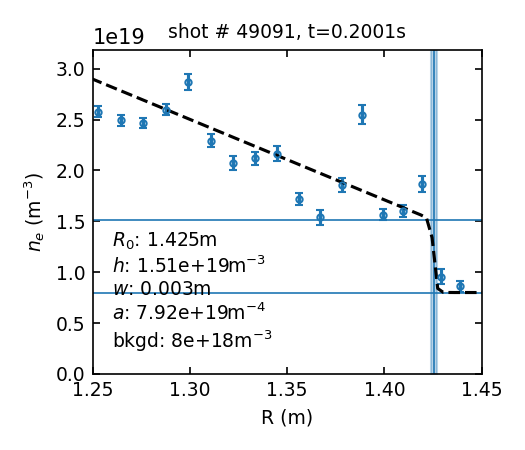

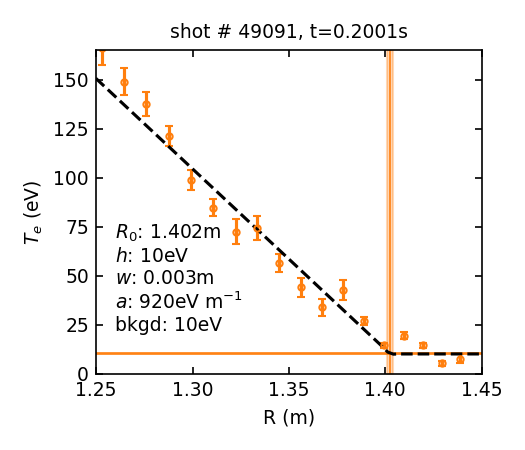

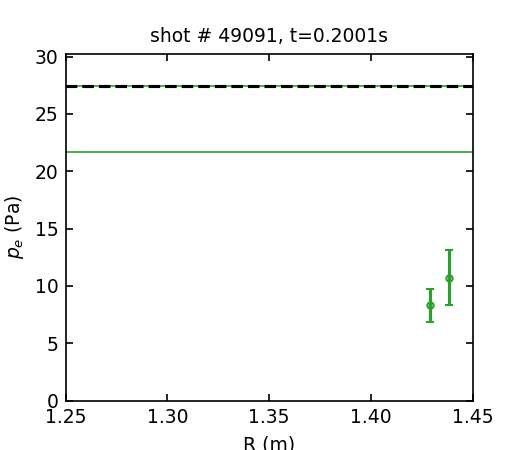

In [13]:
shotn = 49091
twant = time[0]
R0 = 1.25 # where the fit should be valid to
R1 = 1.45 # for the plots
y0 = 0.
yMult = 1.1 # for the ylim in the plots
dR = 0.01
dyDensity = 0.2e19
dyTemp = 20.
dyPressure = 100.


timePed = client.get('/apf/core/mtanh/lfs/time', shotn).data
tind = HSV.findNearest(timePed, twant)


R0Density = client.get('/apf/core/mtanh/lfs/n_e/pedestal_location', shotn).data[tind]
heightDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_height', shotn).data[tind]
widthDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_width', shotn).data[tind]
gradDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_top_gradient', shotn).data[tind]
bkgdDensity = client.get('/apf/core/mtanh/lfs/n_e/background_level', shotn).data[tind]
paramsDensity = (
    R0Density, heightDensity, widthDensity, gradDensity, bkgdDensity
)
textDensity = f'\
$R_0$: {R0Density:.3f}m\n\
$h$: {heightDensity:.3g}m$^{{-3}}$\n\
$w$: {widthDensity:.3f}m\n\
$a$: {gradDensity:.3g}m$^{{-4}}$\n\
bkgd: {bkgdDensity:.3g}m$^{{-3}}$'

R0Temp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_location', shotn).data[tind]
heightTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_height', shotn).data[tind]
widthTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_width', shotn).data[tind]
gradTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_top_gradient', shotn).data[tind]
bkgdTemp = client.get('/apf/core/mtanh/lfs/T_e/background_level', shotn).data[tind]
paramsTemp = (
    R0Temp, heightTemp, widthTemp, gradTemp, bkgdTemp
)
textTemp = f'\
$R_0$: {R0Temp:.3f}m\n\
$h$: {heightTemp:.0f}eV\n\
$w$: {widthTemp:.3f}m\n\
$a$: {gradTemp:.0f}eV m$^{{-1}}$\n\
bkgd: {bkgdTemp:.0f}eV'

R0Pressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_location', shotn).data[tind]
heightPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_height', shotn).data[tind]
widthPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_width', shotn).data[tind]
gradPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_top_gradient', shotn).data[tind]
bkgdPressure = client.get('/apf/core/mtanh/lfs/p_e/background_level', shotn).data[tind]
paramsPressure = (
    R0Pressure, heightPressure, widthPressure, gradPressure, bkgdPressure
)
textPressure = f'\
$R_0$: {R0Pressure:.3f}m\n\
$h$: {heightPressure:.0f}Pa\n\
$w$: {widthPressure:.3f}m\n\
$a$: {gradPressure:.0f}Pa m$^{{-1}}$\n\
bkgd: {bkgdPressure:.0f}Pa'


Rind = HSV.findNearest(RgridB, R0)
profileDensity = mtanh(RgridB, *paramsDensity)
y1Density = profileDensity[Rind] * yMult
profileTemp = mtanh(RgridB, *paramsTemp)
y1Temp = profileTemp[Rind] * yMult
profilePressure = mtanh(RgridB, *paramsPressure)
y1Pressure = profilePressure[Rind] * yMult


timeThomson = client.get('/ayc/time', shotn).data
tind0 = HSV.findNearest(timeThomson, twant)

ne, neErr, RThomson = mf.getNe(shotn)
ne = ne.data[tind0]
neErr = neErr[tind0]

Te, TeErr, _ = mf.getTe(shotn)
Te = Te.data[tind0]
TeErr = TeErr[tind0]

Pe, PeErr, _ = mf.getPe(shotn)
Pe = Pe.data[tind0]
PeErr = PeErr[tind0]

RThomson = RThomson[tind0]


fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [heightDensity, heightDensity], '-', c='C0', lw=0.8)
ax.plot([R0, R1], [bkgdDensity, bkgdDensity], '-', c='C0', lw=0.8)
ax.plot([R0Density, R0Density], [y0, y1Density], '-', c='C0', lw=0.8)
ax.fill_between(
    [R0Density-widthDensity*0.5, R0Density+widthDensity*0.5], 
    [y0, y0], [y1Density, y1Density], color='C0', alpha=0.3, 
)
ax.errorbar(RThomson, ne, yerr=neErr, fmt='.', c='C0', mfc='None', capsize=2)
ax.plot(RgridB, profileDensity, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Density])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$n_e$ (m$^{-3}$)', fontsize=9)
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
              left=True, bottom=True, right=True, top=True)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyDensity, textDensity, ha='left', va='bottom', fontsize=9)
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [heightTemp, heightTemp], '-', c='C1', lw=0.8)
ax.plot([R0, R1], [bkgdTemp, bkgdTemp], '-', c='C1', lw=0.8)
ax.plot([R0Temp, R0Temp], [y0, y1Temp], '-', c='C1', lw=0.8)
ax.fill_between(
    [R0Temp-widthTemp*0.5, R0Temp+widthTemp*0.5], 
    [y0, y0], [y1Temp, y1Temp], color='C1', alpha=0.3, 
)
ax.errorbar(RThomson, Te, yerr=TeErr, fmt='.', c='C1', mfc='None', capsize=2)
ax.plot(RgridB, profileTemp, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Temp])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$T_e$ (eV)', fontsize=9)
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
              left=True, bottom=True, right=True, top=True)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyTemp, textTemp, ha='left', va='bottom', fontsize=9)
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [heightPressure, heightPressure], '-', c='C2', lw=0.8)
ax.plot([R0, R1], [bkgdPressure, bkgdPressure], '-', c='C2', lw=0.8)
ax.plot([R0Pressure, R0Pressure], [y0, y1Pressure], '-', c='C2', lw=0.8)
ax.fill_between(
    [R0Pressure-widthPressure*0.5, R0Pressure+widthPressure*0.5], 
    [y0, y0], [y1Pressure, y1Pressure], color='C2', alpha=0.3, 
)
ax.errorbar(RThomson, Pe, yerr=PeErr, fmt='.', c='C2', mfc='None', capsize=2)
ax.plot(RgridB, profilePressure, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Pressure])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$p_e$ (Pa)', fontsize=9)
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
              left=True, bottom=True, right=True, top=True)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyPressure, textPressure, ha='left', va='bottom', fontsize=9)
plt.tight_layout()

In [14]:
excit = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec12#h_pju#h0.npz')
ne0 = excit['ne'][13:20]
Te0 = excit['Te'][4:23]
dataExcite = excit['data'][13:20,4:23]
### units of [ph m^3 /s]
recom = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec12#h_pju#h0.npz')
dataRecomb = recom['data'][13:20,4:23]
### units of [ph m^3 /s]
ionis = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/IONIS_scd12h.npz')
dataIonise = ionis['data'][13:20,4:23]
### units of [m^3 /s]

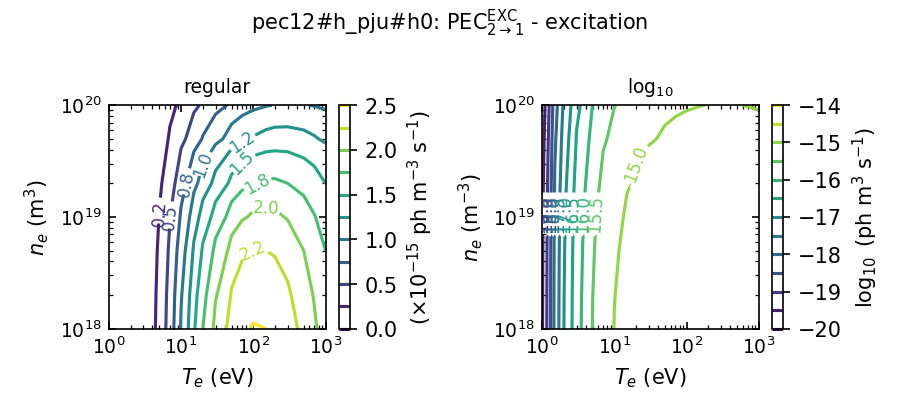

In [15]:
cmap=plt.cm.viridis

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 15
levels = np.linspace(0., 2.5e-15*(10**N), 11)
cf = ax[0].contour(Te0, ne0, dataExcite*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^{{-3}}$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^3$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-20, -14, 13)
cf = ax[1].contour(Te0, ne0, np.log10(dataExcite), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec12#h_pju#h0: PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_5193/2186880549.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fExciteLinear = interp2d(Te0, ne0, dataExcite, kind='linear', bounds_error=True)
/tmp/ipykernel_5193/2186880549.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, pref

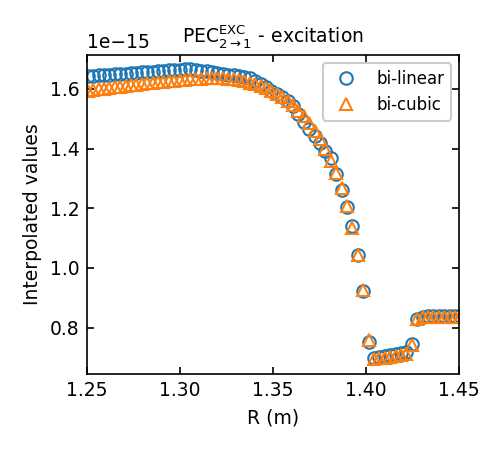

In [16]:
### excitation
fExciteLinear = interp2d(Te0, ne0, dataExcite, kind='linear', bounds_error=True)
fExciteCubic = interp2d(Te0, ne0, dataExcite, kind='cubic', bounds_error=True)

exciteLinear = np.diag(fExciteLinear(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
exciteCubic = np.diag(fExciteCubic(profileTemp[Rind:], profileDensity[Rind:]))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(RgridB[Rind:], exciteLinear, 'o', c='C0', mfc='None', label='bi-linear')
ax.plot(RgridB[Rind:], exciteCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

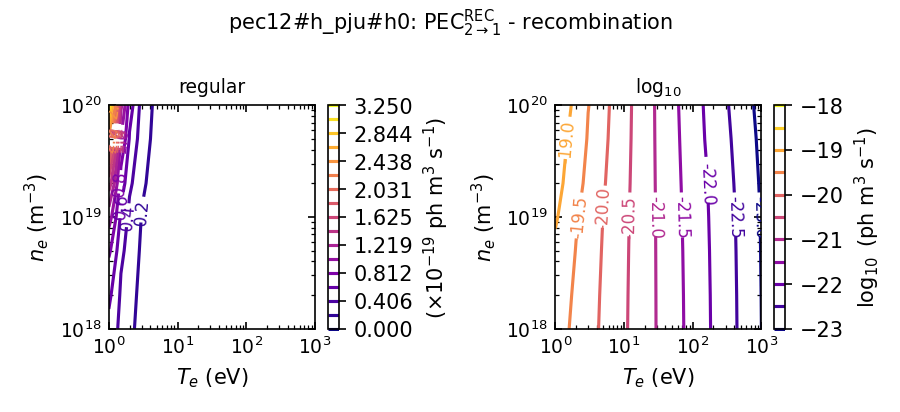

In [17]:
cmap=plt.cm.plasma

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 19
levels = np.linspace(0., 3.25e-19*(10**N), 17)
cf = ax[0].contour(Te0, ne0, dataRecomb*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^3$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-23, -18, 11)
cf = ax[1].contour(Te0, ne0, np.log10(dataRecomb), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec12#h_pju#h0: PEC$^\\mathrm{REC}_{2 \\rightarrow 1}$ - recombination', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_5193/3583168291.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fRecombLinear = interp2d(Te0, ne0, dataRecomb, kind='linear', bounds_error=True)
/tmp/ipykernel_5193/3583168291.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, pref

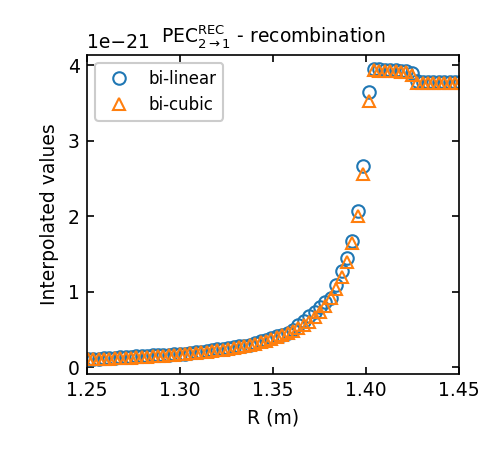

In [18]:
### recombination
fRecombLinear = interp2d(Te0, ne0, dataRecomb, kind='linear', bounds_error=True)
fRecombCubic = interp2d(Te0, ne0, dataRecomb, kind='cubic', bounds_error=True)

recombLinear = np.diag(fRecombLinear(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
recombCubic = np.diag(fRecombCubic(profileTemp[Rind:], profileDensity[Rind:]))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(RgridB[Rind:], recombLinear, 'o', c='C0', mfc='None', label='bi-linear')
ax.plot(RgridB[Rind:], recombCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('PEC$^\\mathrm{REC}_{2 \\rightarrow 1}$ - recombination', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

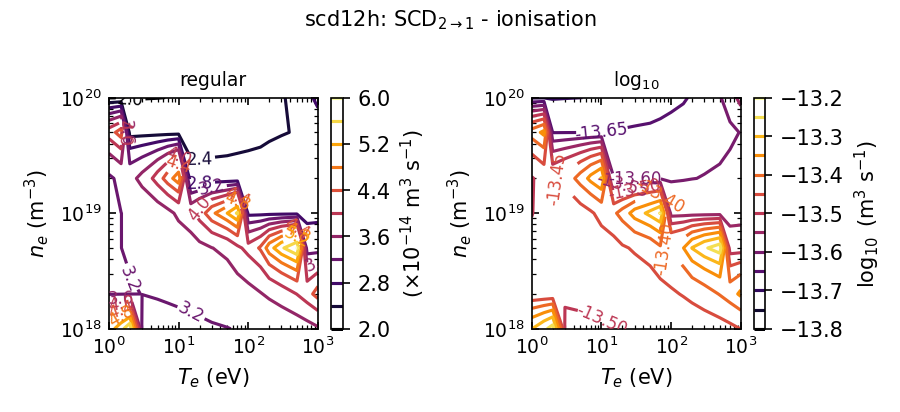

In [19]:
cmap=plt.cm.inferno

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 14
levels = np.linspace(2e-14*(10**N), 6e-14*(10**N), 11)
cf = ax[0].contour(Te0, ne0, dataIonise*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ m$^3$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-13.8, -13.2, 13)
cf = ax[1].contour(Te0, ne0, np.log10(dataIonise), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.2f', inline_spacing=5, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('scd12h: SCD$_{2 \\rightarrow 1}$ - ionisation', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_5193/3512471050.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fIoniseLinear = interp2d(Te0, ne0, dataIonise, kind='linear', bounds_error=True)
/tmp/ipykernel_5193/3512471050.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, pref

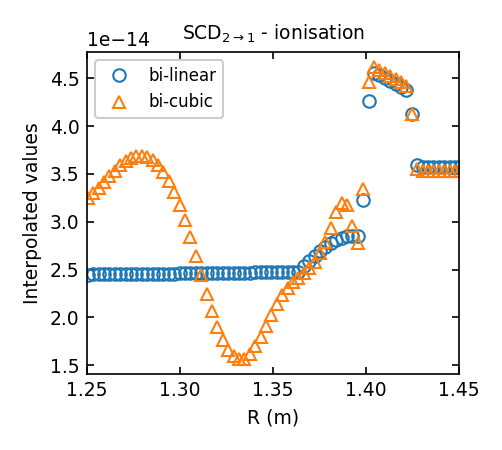

In [20]:
### recombination
fIoniseLinear = interp2d(Te0, ne0, dataIonise, kind='linear', bounds_error=True)
fIoniseCubic = interp2d(Te0, ne0, dataIonise, kind='cubic', bounds_error=True)

ioniseLinear = np.diag(fIoniseLinear(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
ioniseCubic = np.diag(fIoniseCubic(profileTemp[Rind:], profileDensity[Rind:]))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(RgridB[Rind:], ioniseLinear, 'o', c='C0', mfc='None', label='bi-linear')
ax.plot(RgridB[Rind:], ioniseCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('SCD$_{2 \\rightarrow 1}$ - ionisation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

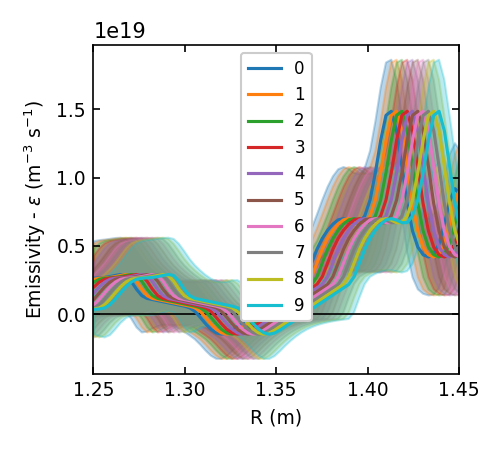

In [21]:
### testing the location moving of the emissivity
fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot([R0, R1], [0., 0.], '-k', lw=0.8)
ax.set_xlim([R0, R1])
ax.plot(RgridB[Rind:], y[0][Rind:], c='C0', label=f'{0}')
ax.fill_between(
    RgridB[Rind:], y[0][Rind:]-yErr[0][Rind:], 
    y[0][Rind:]+yErr[0][Rind:], color='C0', alpha=0.3
)
for i in range(1, 10):
    ax.plot(RgridB[Rind:], y[0][Rind-i:-i], c=f'C{i}', label=f'{i}')
    ax.fill_between(
        RgridB[Rind:], y[0][Rind-i:-i]-yErr[0][Rind-i:-i], 
        y[0][Rind-i:-i]+yErr[0][Rind-i:-i], color=f'C{i}', alpha=0.3
    )
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Emissivity - $\\epsilon$ (m$^{-3}$ s$^{-1}$)', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
plt.tight_layout()

In [22]:
def calcSiz(emissivity, temperature, density, fExcite, fIonise, pi=False):
    SCD = np.diag(fIonise(temperature, density))[::-1]
    EXC = np.diag(fExcite(temperature, density))[::-1]
    ionisation = emissivity * SCD / EXC
    if pi:
        ionionsation *= (4. * np.pi)
    return ionisation


def calcN0(emissivity, temperature, density, fExcite, fRecomb, pi=False):
    REC = np.diag(fRecomb(temperature, density))[::-1] * density * density
    EXC = np.diag(fExcite(temperature, density))[::-1] * density
    if pi:
        A = 4. * np.pi
    else:
        A = 1.
    n0 = ((A * emissivity) - REC) / EXC
#     print(emissivity)
#     print(REC)
#     print(EXC)
    return n0

In [23]:
def wrapper(I, R1=1.45):
    if I != 0:
        J = -I
    else:
        J = None
    
    
    Siz = calcSiz(y[0][Rind-I:J], profileTemp[Rind:], profileDensity[Rind:], fExciteCubic, fIoniseLinear, pi=False)
    n0 = calcN0(y[0][Rind-I:J], profileTemp[Rind:], profileDensity[Rind:], fExciteCubic, fRecombCubic, pi=False)


    fig, ax = plt.subplots(1, 3, figsize=(6,3), dpi=150)

    ax[0].plot(RgridB[Rind:], y[0][Rind:], 'o', c='C0', mfc='None')
    ax[0].fill_between(
        RgridB[Rind:], y[0][Rind:]-yErr[0][Rind:], 
        y[0][Rind:]+yErr[0][Rind:], color='C0', alpha=0.3
    )
    ax[0].set_title('Emissivity', fontsize=9)
    ax[0].set_xlabel('R (m)')
    ax[0].set_ylabel('$\\epsilon$ (m$^{-3}$ s$^{-1}$)')
    ax[0].yaxis.get_offset_text().set_size(9)

    ax[1].plot(RgridB[Rind:], Siz, '^', c='C1', mfc='None')
    ax[1].set_title('Ionisation rate', fontsize=9)
    ax[1].set_xlabel('R (m)')
    ax[1].set_ylabel('$S_\\mathrm{iz}$ (m$^{-3}$ s$^{-1}$)')
    ax[1].yaxis.get_offset_text().set_size(9)

    ax[2].plot(RgridB[Rind:], n0, 's', c='C2', mfc='None')
    ax[2].set_title('Neutral density', fontsize=9)
    ax[2].set_xlabel('R (m)')
    ax[2].set_ylabel('$n_0$ (m$^{-3}$)')
    ax[2].yaxis.get_offset_text().set_size(9)

    fig.suptitle(f'Displace emissivity by {I}')
    for i in range(0, 3):
        ax[i].plot([R0, R1], [0., 0.], '-k', lw=0.8)
        ax[i].set_xlim([R0, R1])
        ax[i].tick_params(
            axis="both", which='both', labelsize=9, direction='in', 
            left=True, bottom=True, right=True, top=True
        )
    plt.tight_layout()
    return

/tmp/ipykernel_5193/555380902.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  SCD = np.diag(fIonise(temperature, density))[::-1]
/tmp/ipykernel_5193/555380902.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`Cl

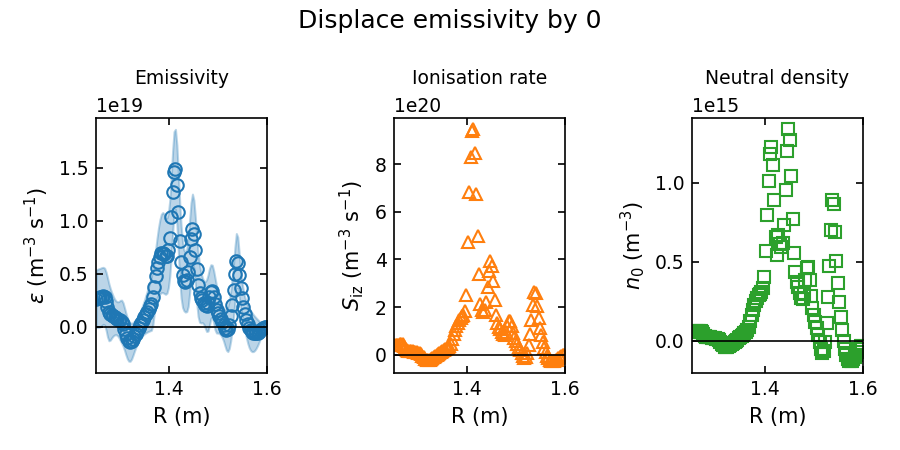

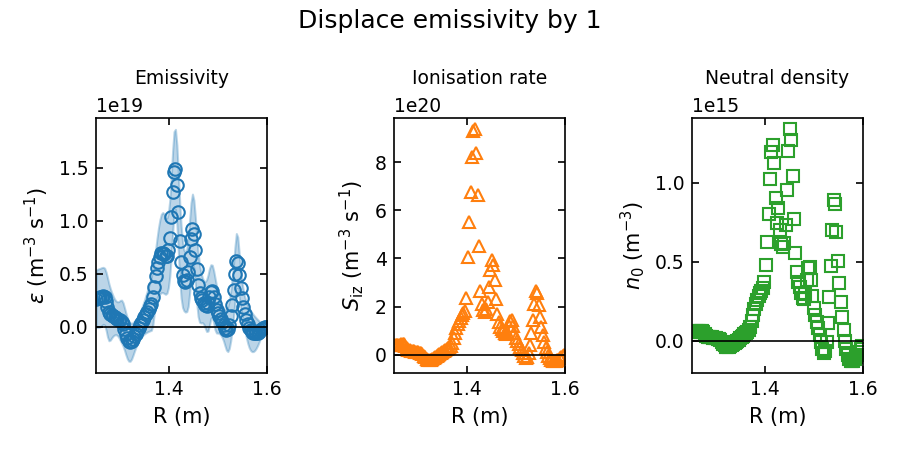

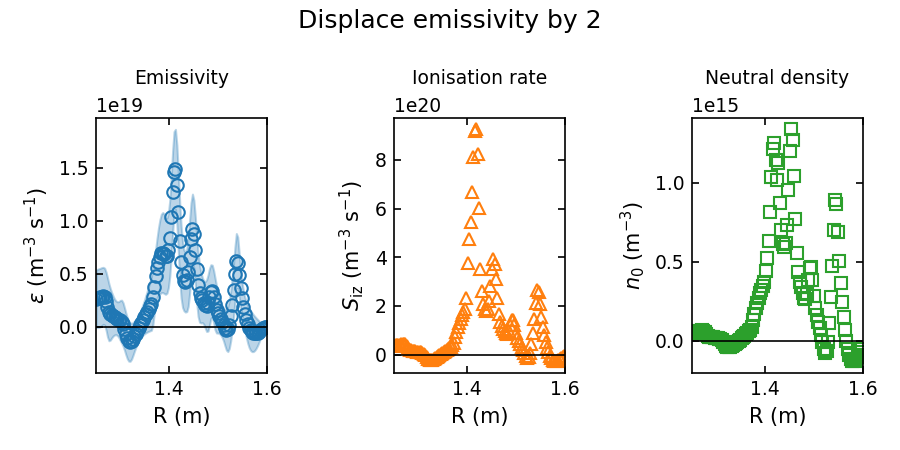

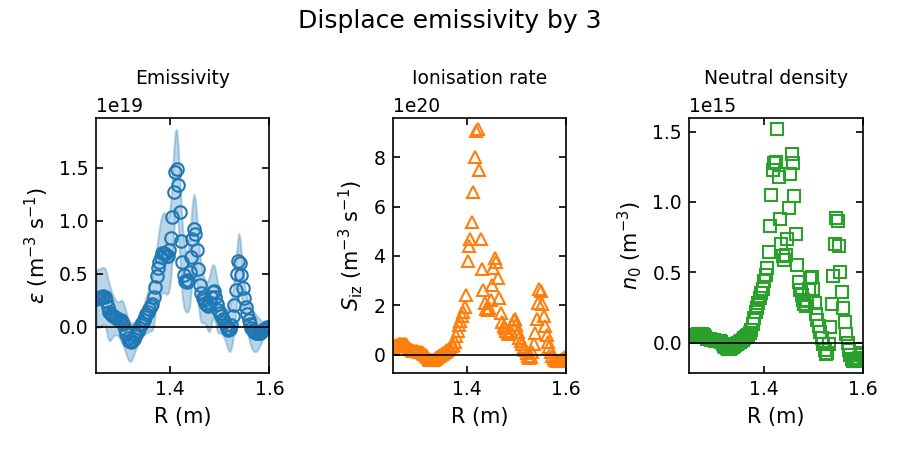

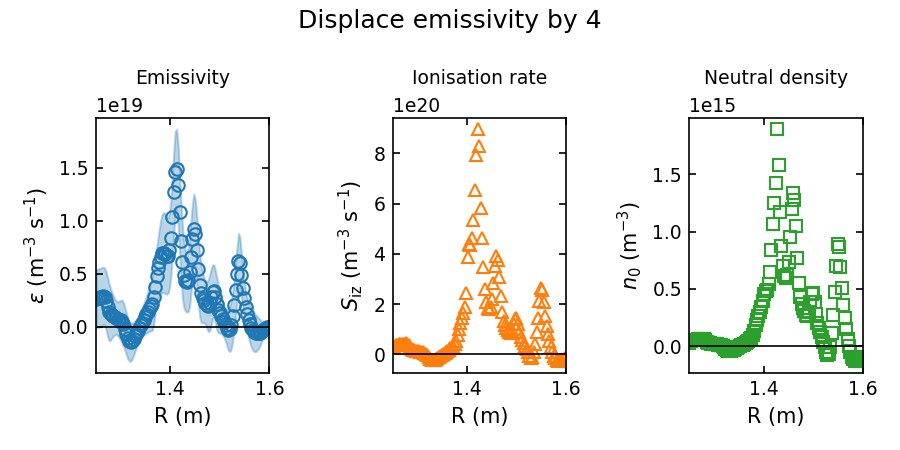

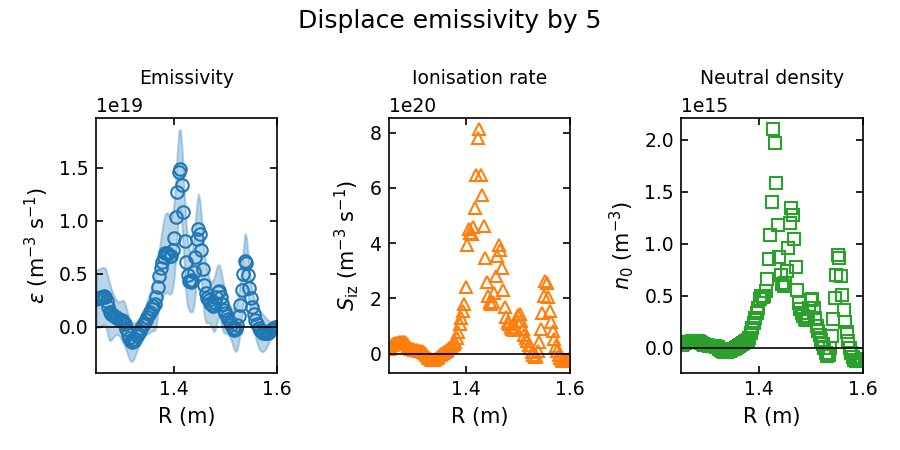

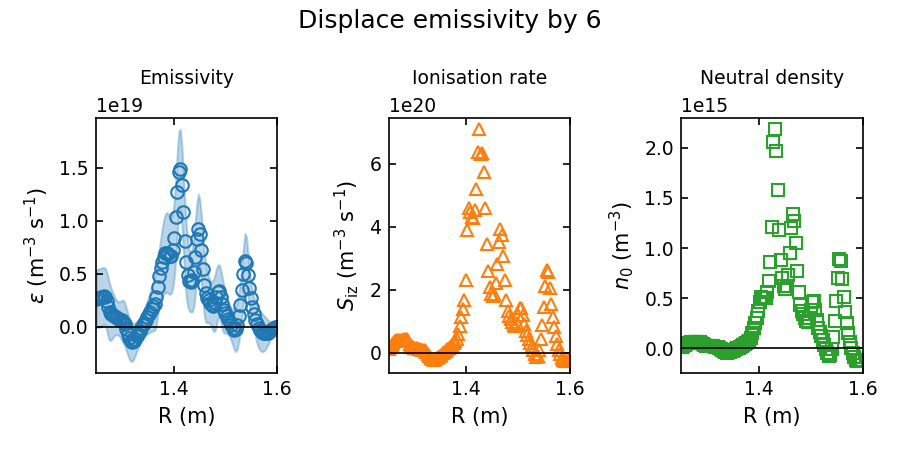

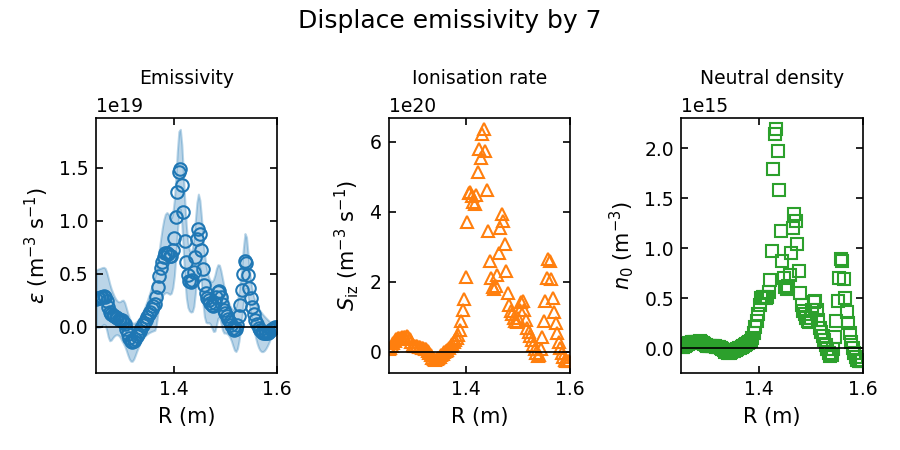

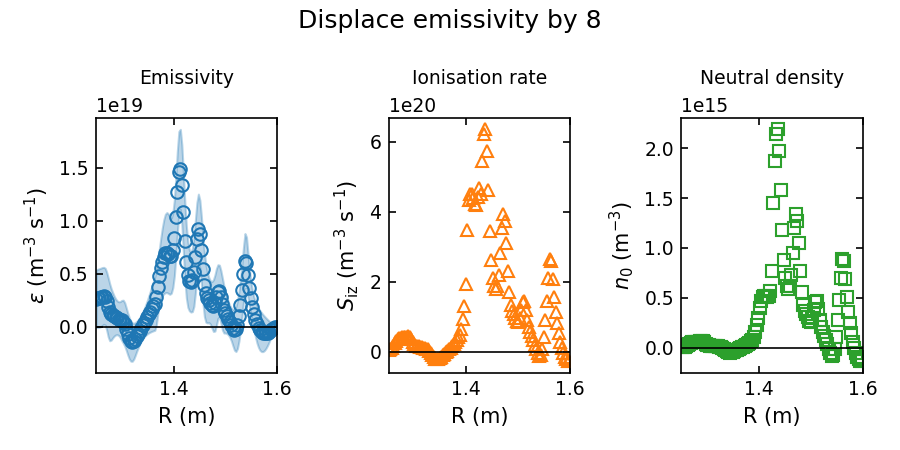

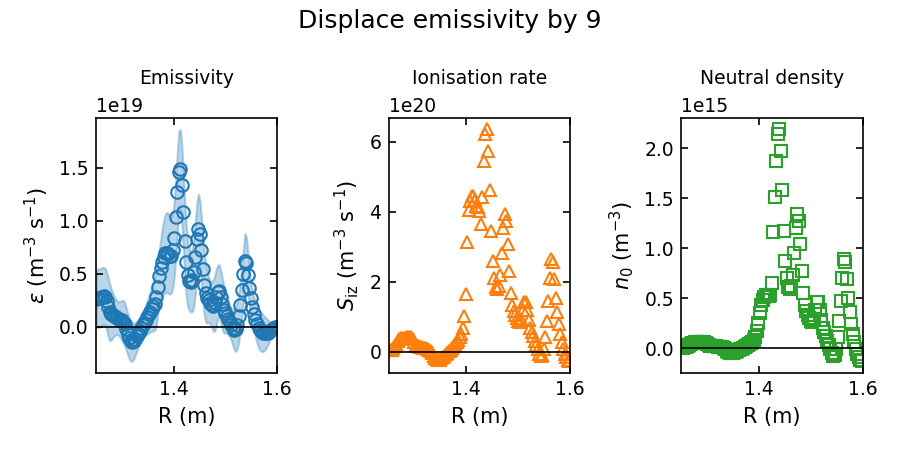

In [24]:
for I in range(0, 10):
    wrapper(I, R1=1.6)